# BBOXX solar-home-system batteries

This notebook lists the released batteries with their repair labels, loads one battery as released, and plots its voltage over one week. It makes no diagnosis.

## 1. Released units

This step lists what `systems('aitio')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('aitio')
display(released)

,unit,zip,member,ACTIVATED,IN_REPAIR_SYSTEM,STILL_ALIVE,Lifetime
0,0,set_0.zip,0.npz,2019-01-31,NaT,True,593
1,1,set_0.zip,1.npz,2018-12-04,NaT,True,651
2,2,set_1.zip,2.npz,2019-04-18,NaT,True,516
3,3,set_2.zip,3.npz,2019-03-05,NaT,True,560
4,4,set_3.zip,4.npz,2018-12-06,NaT,True,649
...,...,...,...,...,...,...,...
1022,1022,set_0.zip,1022.npz,2018-11-03,2020-09-11,False,678
1023,1023,set_0.zip,1023.npz,2018-12-28,2020-06-03,False,523
1024,1024,set_0.zip,1024.npz,2019-01-10,2020-06-11,False,518
1025,1025,set_0.zip,1025.npz,2018-09-05,2020-02-09,False,522


Each row is one battery, one .npz file inside one of the shipped zips, joined with meta_data.csv. STILL_ALIVE is FALSE for the 491 batteries that entered repair for capacity loss. The authors chose this roughly balanced split, so it is not a failure rate.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('aitio', unit='0')
print(frame.shape)
display(frame.head())

(787789, 4)


,time_s,current_A,voltage_V,temperature_degC
time,,,,
2019-01-31 11:20:58+00:00,1.548934e+09,0.019074,12.662547,32.249943
2019-01-31 11:30:58+00:00,1.548934e+09,0.020981,12.657359,32.373541
2019-01-31 11:40:58+00:00,1.548935e+09,0.019074,12.657359,32.748913
2019-01-31 11:50:58+00:00,1.548935e+09,0.019074,12.657359,32.623026
2019-01-31 11:59:38.099999905+00:00,1.548936e+09,0.020981,12.657359,32.623026


One battery at a median 60 s interval, indexed by UTC time. Current is negative while charging, as the readme states.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['current_A', 'voltage_V', 'temperature_degC']].describe().T)

,count,mean,std,min,25%,50%,75%,max
current_A,787789.0,-0.027743,0.799188,-3.674144,-0.398032,0.128176,0.369268,2.755627
voltage_V,787789.0,12.965273,0.658622,0.010071,12.442817,12.749523,13.418479,14.532082
temperature_degC,787789.0,33.769982,3.184908,25.124743,31.249714,33.623255,35.999084,43.749142


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

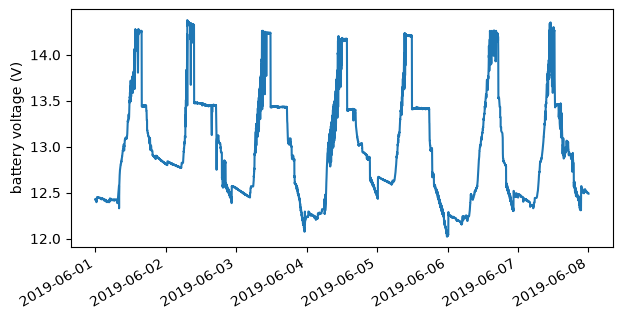

In [4]:
week = frame.loc['2019-06-01':'2019-06-07']
ax = week['voltage_V'].plot(figsize=(7, 3.5))
ax.set_xlabel('')
ax.set_ylabel('battery voltage (V)')
plt.show()

Over the week of 1 to 7 June 2019 the raw voltage of battery 0 stays between 12.0 and 14.4 V, with a median of 12.9 V.